In [1]:
from pctk import multicellds
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.io

from scipy.interpolate import griddata

In [64]:
output_folder = "../../../../output/"

In [9]:
mcds_reader = multicellds.MultiCellDS(output_folder)
vol_idx = 4
name2idx = {n:i for i,n in enumerate(mcds_reader.cell_columns)}

data = []
for t, a in mcds_reader.microenvironment_as_matrix_iterator():
    data.append((t/60., (a[5].sum() / len(a[5])), (a[6].sum() / len(a[6])), (a[4].sum() / len(a[4])) ))

df_substrates = pd.DataFrame(data=data, columns=["time", "glucose", "acetate", "oxygen"]).set_index("time")

data = []
for t, a in mcds_reader.cells_as_matrix_iterator():
    total_volume = a[:,4].sum() # um3
    scaled_volume = total_volume / 10**12 # mL
    density = 1.04 # g/ml
    solid_fraction = 0.25
    biomass = scaled_volume * density * solid_fraction / 2e-8 
    #print("total volume is ", total_volume)
    
    data.append((t/60, a.shape[0], a[:,-2].max(), a[:,-1].max(), biomass, a[:,-4].mean(), a[:,-5].mean()))

df_cells = pd.DataFrame(data=data, columns=["time", "n_cells", "growth_rate", "growth_factor", "total_biomass", "acetate", "glucose"])

Text(0.5, 0, 'Time (hours)')

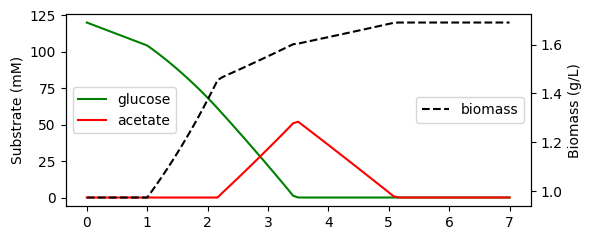

In [10]:
fig, ax = plt.subplots(1,1,figsize=(6,2.5), sharex=True)
s = "glucose"
ax.plot(df_substrates[s], label=s, c='g')
s = "acetate"
ax.plot(df_substrates[s], label=s, c='r')
ax.legend(loc=6)
ax.set_ylabel("Substrate (mM)")
ax = ax.twinx()
ax.plot(df_cells['time'], df_cells['total_biomass'], 'k--', label="biomass")
ax.set_ylabel("Biomass (g/L)")
ax.legend(loc=5)
ax.set_xlabel("Time (hours)")

Text(0, 0.5, 'Exchange flux')

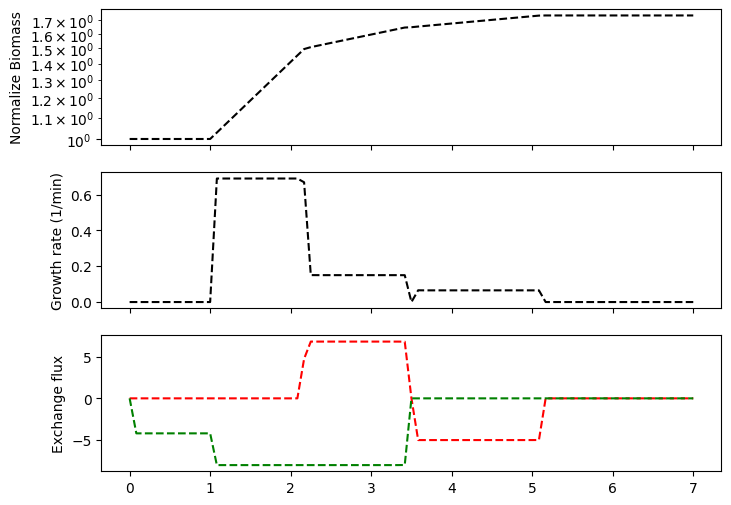

In [11]:
fig, axes = plt.subplots(3,1,figsize=(8,6), sharex=True)

ax = axes[0]
ax.plot(df_cells['time'], df_cells['total_biomass']/df_cells.loc[0, 'total_biomass'], 'k--')
ax.set_yscale('log')
ax.set_ylabel("Normalize Biomass")

ax = axes[1]
ax.plot(df_cells['time'], df_cells['growth_rate'], 'k--')
ax.set_ylabel("Growth rate (1/min)")


ax = axes[2]
ax.plot(df_cells['time'], df_cells['acetate'], 'r--', label="acetate")
ax.plot(df_cells['time'], df_cells['glucose'], 'g--', label="glucose")
ax.set_ylabel("Exchange flux")

In [12]:
mask = df_cells["growth_rate"] > 0

df = df_cells.loc[mask, ["growth_rate", "growth_factor"]]

df['test'] = np.exp(df["growth_rate"]/60. * 0.01)

df

,growth_rate,growth_factor,test
13,0.690585,0.0,1.000115
14,0.690585,0.0,1.000115
15,0.690584,0.0,1.000115
16,0.690584,0.0,1.000115
17,0.690584,0.0,1.000115
18,0.690584,0.0,1.000115
19,0.690583,0.0,1.000115
20,0.690583,0.0,1.000115
21,0.690583,0.0,1.000115
22,0.690582,0.0,1.000115


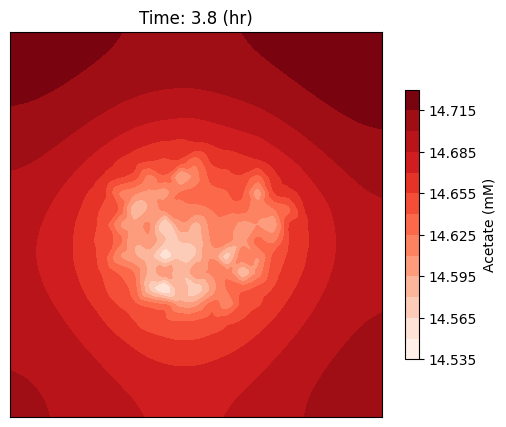

In [19]:
# Load one time step
step = 45
time = step * 5 / 60
mat = scipy.io.loadmat(output_folder + f"output000000{step:2}_microenvironment0.mat")
M = mat["multiscale_microenvironment"]

x = M[0,:]
y = M[1,:]
z = M[2,:]
substrate = M[6,:] / 3  # usually the first substrate, check your XML
# substrate[0] = 0.1
substrate_name = "Oxygen"

# Determine grid size
nx = len(np.unique(x))
ny = len(np.unique(y))


xi = np.linspace(x.min(), x.max(), 200)  # finer grid
yi = np.linspace(y.min(), y.max(), 200)
Xi, Yi = np.meshgrid(xi, yi)

from scipy.interpolate import griddata
Zi = griddata((x, y), substrate, (Xi, Yi), method='cubic')  # smooth interpolation

fig,ax = plt.subplots(1,1,figsize=(6,5))
im = ax.contourf(Xi, Yi, Zi, levels=15, cmap='Reds')
plt.colorbar(im, label=f'{substrate_name} (mM)', ax=ax, shrink=0.7)
ax.set_title(f'Time: {time:.1f} (hr)')
ax.set_xticks([])
ax.set_yticks([])

fig.savefig(f"./figs/{substrate_name}_{time:.1f}h.svg")

In [21]:
reader = multicellds.MultiCellDS(output_folder=output_folder)
reader.microenvironment_columns

[('oxygen', 'dimensionless', '0'),
 ('glucose', 'dimensionless', '1'),
 ('acetate', 'dimensionless', '2'),
 ('CO2', 'dimensionless', '3')]

## Substrate Dynamics Visualization

Create contour plots for all three substrates (glucose, acetate, oxygen) at multiple time points to visualize the spatiotemporal dynamics.

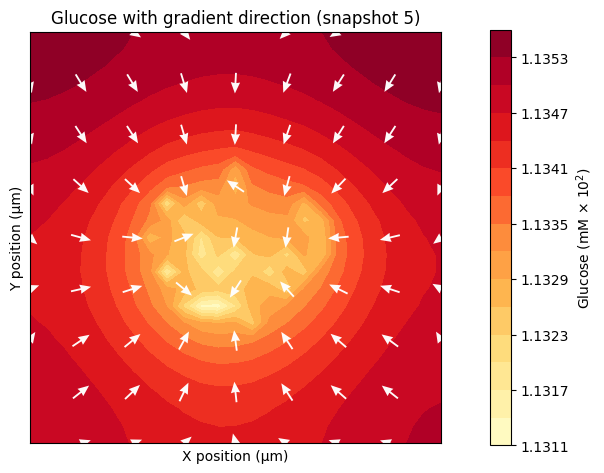

In [141]:
# Contour + gradient arrows using reader.microenvironment_as_matrix_iterator() (sparser/smaller arrows)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# --- Parameters ---
target_index = 5          # snapshot index to visualize (0-based over the iterator)
substrate = 'glucose'      # one of: 'oxygen', 'glucose', 'acetate', 'co2'
levels = 15
arrow_target = 8           # fewer arrows
arrow_length_frac = 0.05   # smaller arrows
grad_threshold_pct = 10    # draw arrows above this percentile of gradient magnitude
# ------------------

# Helper: reshape native scattered vectors to a regular grid based on unique coordinates
def _reshape_to_grid(x, y, v):
    xu = np.unique(x); yu = np.unique(y)
    nx, ny = xu.size, yu.size
    if nx * ny != v.size:
        raise ValueError(f"Cannot reshape: expected {nx}*{ny}={nx*ny} points, got {v.size}")
    ix = np.searchsorted(xu, x)
    iy = np.searchsorted(yu, y)
    Z = np.full((ny, nx), np.nan)
    Z[iy, ix] = v
    dx = np.diff(xu).mean() if nx>1 else 1.0
    dy = np.diff(yu).mean() if ny>1 else 1.0
    Xg, Yg = np.meshgrid(xu, yu, indexing='xy')
    return Xg, Yg, Z, dx, dy

# Collect the desired snapshot from the iterator
selected = None
for idx, (t, a) in enumerate(reader.microenvironment_as_matrix_iterator()):
    if idx == target_index:
        selected = (t, a)
        break

if selected is None:
    raise IndexError(f"target_index {target_index} not found; try a smaller value.")

# Unpack and build the field
_, A = selected
x = A[0, :]
y = A[1, :]
sub_idx = MICROENV_COLS.index(substrate)
vals = A[sub_idx, :]

Xg, Yg, Z, dx, dy = _reshape_to_grid(x, y, vals)

# Compute gradients on native grid
Z_med = np.nanmedian(Z) if np.isfinite(Z).any() else 0.0
Zg = np.where(np.isfinite(Z), Z, Z_med)
dZdy, dZdx = np.gradient(Zg, dy, dx)
U = -dZdx
V = -dZdy
mag = np.hypot(U, V)

# Subsample vectors
sx = max(1, Z.shape[1] // arrow_target)
sy = max(1, Z.shape[0] // arrow_target)
Xs = Xg[::sy, ::sx]; Ys = Yg[::sy, ::sx]
Us = U[::sy, ::sx]; Vs = V[::sy, ::sx]; Ms = mag[::sy, ::sx]
finite = np.isfinite(Ms)
th = np.percentile(Ms[finite], grad_threshold_pct) if finite.any() else np.inf
mask = finite & (Ms > th)

# Normalize and scale arrow length in data units
Msafe = np.where(Ms == 0, 1.0, Ms)
Un = Us / Msafe
Vn = Vs / Msafe
L = min(Xg.max() - Xg.min(), Yg.max() - Yg.min()) * arrow_length_frac

# Move scientific exponent into label by scaling the field
finite_Z = Z[np.isfinite(Z)]
if finite_Z.size:
    peak = np.nanmax(np.abs(finite_Z))
    exp = int(np.floor(np.log10(peak))) if peak > 0 else 0
else:
    exp = 0
use_exp = (abs(exp) >= 2)
scale = 10.0 ** exp if use_exp else 1.0
Z_disp = Z / scale

# Plot
fig, ax = plt.subplots(1, 1, figsize=(6.2, 5.2))
cntr = ax.contourf(Xg, Yg, Z_disp, levels=levels, cmap='YlOrRd')
cb = fig.colorbar(cntr, ax=ax, shrink=0.86, pad=0.09)

fmt = ScalarFormatter(useMathText=True)
fmt.set_scientific(False)
cb.ax.yaxis.set_major_formatter(fmt)
cb.update_ticks()
label = f"{substrate.capitalize()} (mM)"
if use_exp and exp != 0:
    label = f"{substrate.capitalize()} (mM × $10^{{{exp}}}$)"
cb.set_label(label)

ax.quiver(
    Xs[mask], Ys[mask], Un[mask]*L, Vn[mask]*L,
    color='white', alpha=0.98, angles='xy', scale_units='xy', scale=1.0,
    width=0.0045, headwidth=5.0, headlength=6.0, headaxislength=5.6, pivot='middle'
)

ax.set_aspect('equal')
ax.set_title(f"{substrate.capitalize()} with gradient direction (snapshot {target_index})")
ax.set_xlabel('X position (μm)')
ax.set_ylabel('Y position (μm)')
ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()


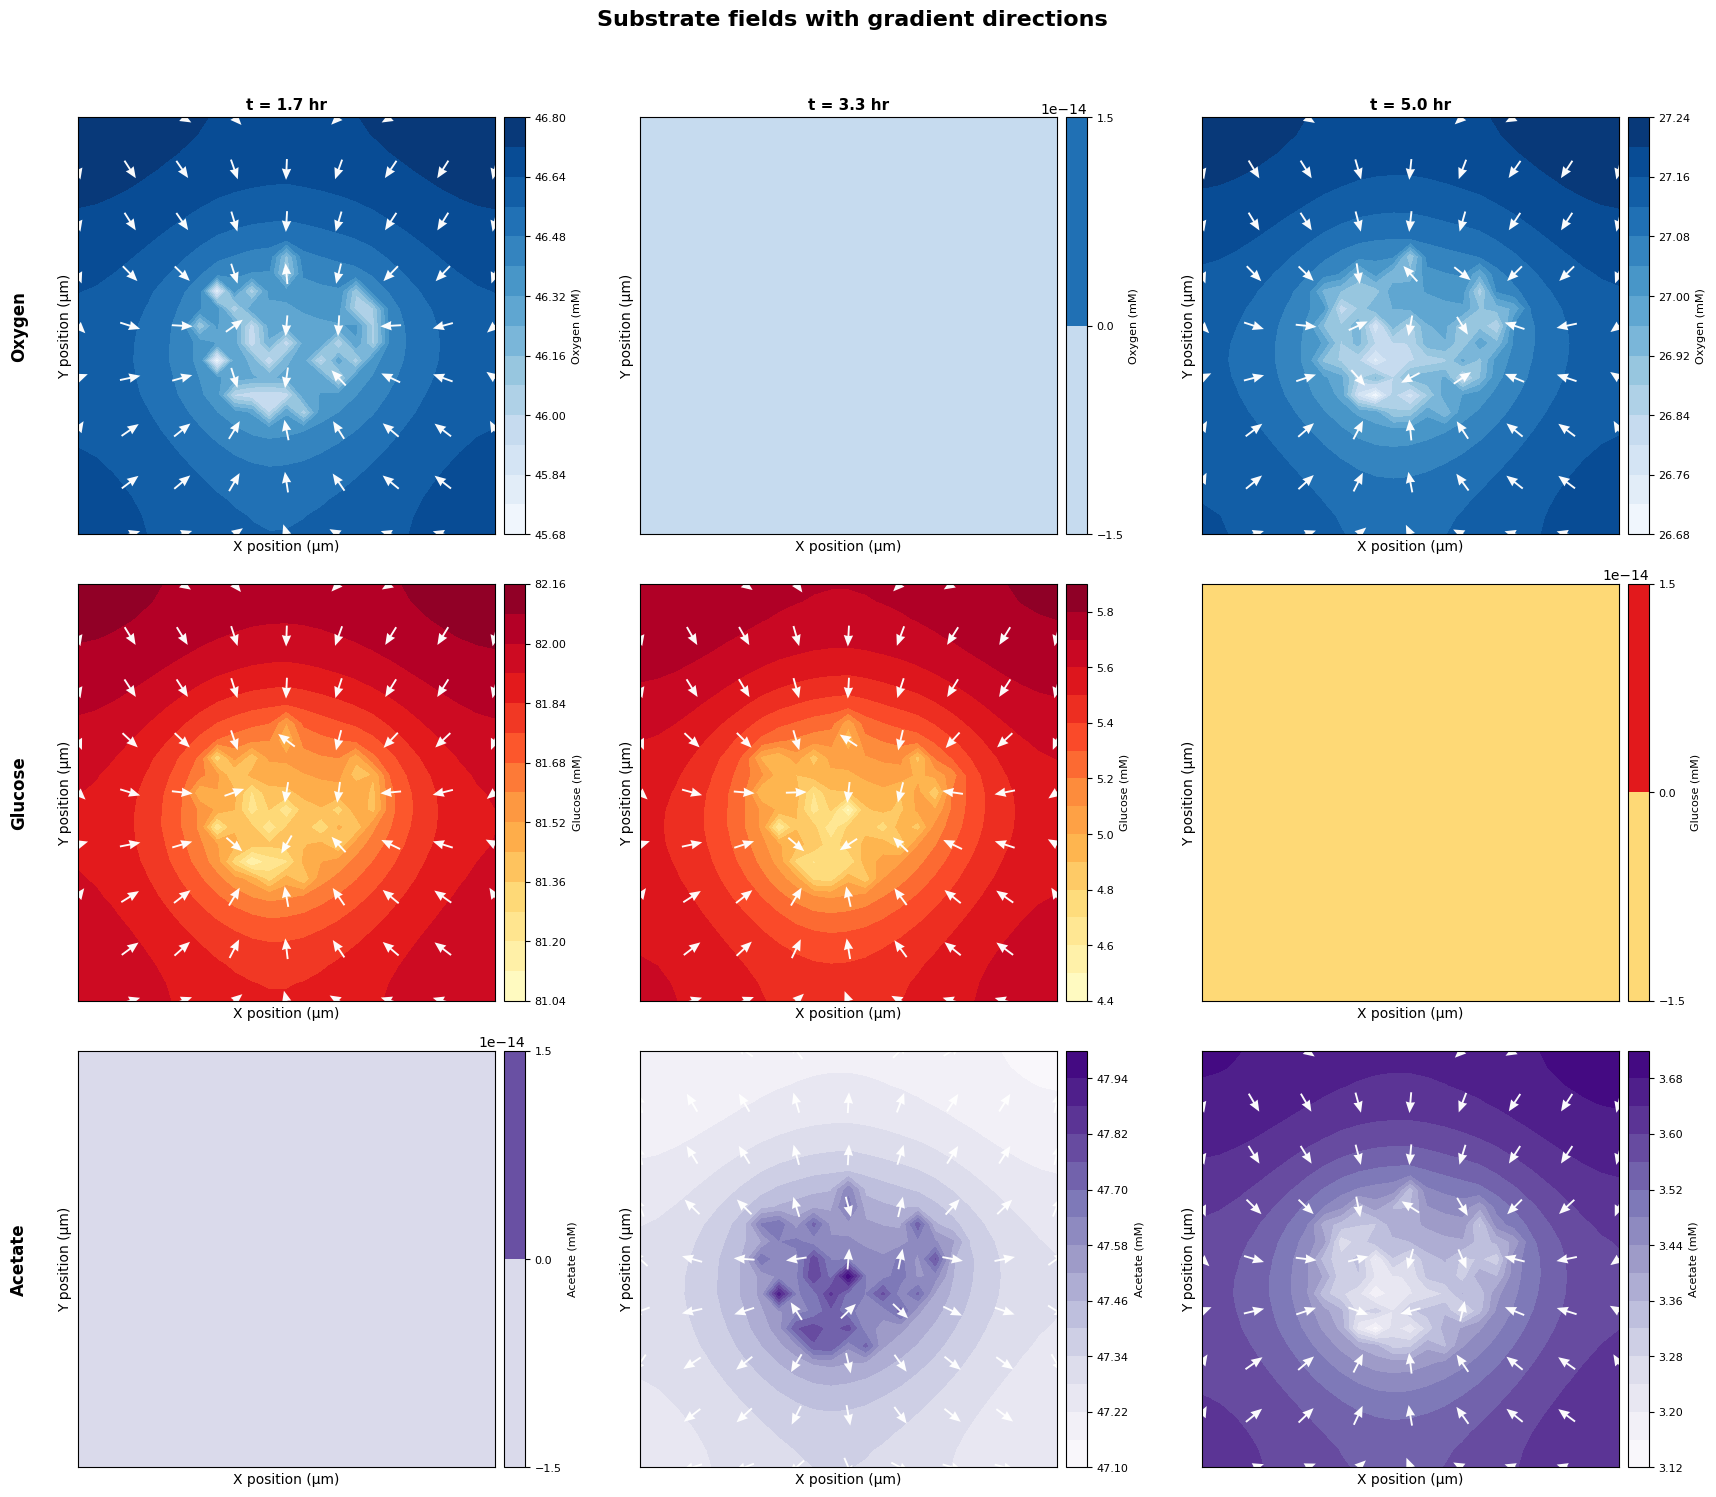

In [147]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# --- you can tweak these ---
time_indices   = [20, 40, 60]              # columns (indices over the iterator)
substrate_rows = ['oxygen','glucose','acetate']  # rows; add 'co2' if you want
levels = 15
arrow_target = 8            # ~how many vectors along each axis
arrow_length_frac = 0.05    # arrow length as a fraction of domain size
grad_threshold_pct = 10     # keep arrows above this percentile of |grad|
cmap = 'YlOrRd'             # per-substrate you can change inside the loop if you want
# ---------------------------

MICROENV_COLS = ['x','y','z','volume','oxygen','glucose','acetate','co2']

def _reshape_to_grid(x, y, v):
    xu = np.unique(x); yu = np.unique(y)
    nx, ny = xu.size, yu.size
    if nx * ny != v.size:
        raise ValueError(f"Cannot reshape: expected {nx}*{ny}={nx*ny} points, got {v.size}")
    ix = np.searchsorted(xu, x)
    iy = np.searchsorted(yu, y)
    Z = np.full((ny, nx), np.nan)
    Z[iy, ix] = v
    dx = np.diff(xu).mean() if nx>1 else 1.0
    dy = np.diff(yu).mean() if ny>1 else 1.0
    Xg, Yg = np.meshgrid(xu, yu, indexing='xy')
    return Xg, Yg, Z, dx, dy

def _soft_zero(Z, abs_eps=1e-12, rel_eps=1e-6, clamp_nonneg=False):
    """Set tiny values to exactly 0 to remove floating noise."""
    Z = Z.copy()
    finite = np.isfinite(Z)
    if not finite.any():
        return Z
    max_abs = np.nanmax(np.abs(Z[finite]))
    eps = max(abs_eps, rel_eps * max_abs) if max_abs > 0 else abs_eps
    Z[np.abs(Z) < eps] = 0.0
    if clamp_nonneg:
        Z[Z < 0] = 0.0
    return Z


# 1) collect only the snapshots we need (single pass over the iterator)
wanted = set(time_indices)
snapshots = {}  # idx -> (t, A)
for idx, (t, a) in enumerate(reader.microenvironment_as_matrix_iterator()):
    if idx in wanted:
        snapshots[idx] = (t, a)
    if len(snapshots) == len(wanted):
        break

missing = [i for i in time_indices if i not in snapshots]
if missing:
    raise IndexError(f"Missing snapshots for indices: {missing}")

# 2) make the panel (rows x cols)
nrows = len(substrate_rows)
ncols = len(time_indices)
fig, axes = plt.subplots(nrows, ncols, figsize=(5.8*ncols, 5.0*nrows))
axes = np.atleast_2d(axes)

for r, sub in enumerate(substrate_rows):
    sub_idx = MICROENV_COLS.index(sub)

    # optional different cmap per substrate
    cmap_r = {'oxygen':'Blues', 'glucose':'YlOrRd', 'acetate':'Purples', 'co2':'Greens'}.get(sub, cmap)

    for c, idx in enumerate(time_indices):
        ax = axes[r, c]
        t, A = snapshots[idx]

        # build field
        x = A[0, :]; y = A[1, :]
        vals = A[sub_idx, :]
        Xg, Yg, Z, dx, dy = _reshape_to_grid(x, y, vals)

        # --- NEW: zero-out tiny numerical noise ---
        clamp_nonneg = (sub in {'oxygen','glucose','acetate','co2'})
        Z = _soft_zero(Z, abs_eps=1e-0, rel_eps=1e-6, clamp_nonneg=clamp_nonneg)
        # -----------------------------------------

        # gradient (fill NaNs with median to stabilize)
        Z_med = np.nanmedian(Z) if np.isfinite(Z).any() else 0.0
        Zg = np.where(np.isfinite(Z), Z, Z_med)
        dZdy, dZdx = np.gradient(Zg, dy, dx)
        U = -dZdx; V = -dZdy
        mag = np.hypot(U, V)

        # subsample arrows
        sx = max(1, Z.shape[1] // arrow_target)
        sy = max(1, Z.shape[0] // arrow_target)
        Xs = Xg[::sy, ::sx]; Ys = Yg[::sy, ::sx]
        Us = U[::sy, ::sx]; Vs = V[::sy, ::sx]; Ms = mag[::sy, ::sx]
        finite = np.isfinite(Ms)
        th = np.percentile(Ms[finite], grad_threshold_pct) if finite.any() else np.inf
        mask = finite & (Ms > th)

        # normalize arrow direction and set fixed display length
        Msafe = np.where(Ms == 0, 1.0, Ms)
        Un = Us / Msafe; Vn = Vs / Msafe
        L = min(Xg.max() - Xg.min(), Yg.max() - Yg.min()) * arrow_length_frac

        # per-panel display scaling (move exponent into label)
        finite_Z = Z[np.isfinite(Z)]
        if finite_Z.size:
            peak = np.nanmax(np.abs(finite_Z))
            exp = int(np.floor(np.log10(peak))) if peak > 0 else 0
        else:
            exp = 0
        use_exp = (abs(exp) >= 2)
        scale = 10.0 ** exp if use_exp else 1.0
        Z_disp = Z / scale

        # plot contour + per-axis colorbar
        cntr = ax.contourf(Xg, Yg, Z_disp, levels=levels, cmap=cmap_r)
        cb = fig.colorbar(cntr, ax=ax, fraction=0.046, pad=0.018)
        fmt = ScalarFormatter(useMathText=True)
        fmt.set_scientific(False)
        cb.ax.yaxis.set_major_formatter(fmt)
        cb.update_ticks()
        label = f"{sub.capitalize()} (mM)"
        if use_exp and exp != 0:
            label = f"{sub.capitalize()} (mM × $10^{{{exp}}}$)"
        cb.set_label(label, fontsize=8)
        cb.ax.tick_params(labelsize=8)

        # arrows
        ax.quiver(
            Xs[mask], Ys[mask], Un[mask]*L, Vn[mask]*L,
            color='white', alpha=0.98, angles='xy', scale_units='xy', scale=1.0,
            width=0.0045, headwidth=5.0, headlength=6.0, headaxislength=5.6, pivot='middle'
        )

        # cosmetics
        if r == 0:
            ax.set_title(f"t = {t/60.0:.1f} hr", fontsize=11, fontweight='bold')
        ax.set_aspect('equal')
        ax.set_xlabel('X position (μm)')
        ax.set_ylabel('Y position (μm)')
        ax.set_xticks([]); ax.set_yticks([])

# row labels on the left margin
for r, sub in enumerate(substrate_rows):
    axes[r, 0].text(-0.12, 0.5, sub.capitalize(), transform=axes[r, 0].transAxes,
                    ha='right', va='center', fontsize=12, fontweight='bold', rotation=90)

fig.suptitle("Substrate fields with gradient directions", fontsize=16, fontweight='bold', y=0.995)
fig.tight_layout(rect=[0,0,1,0.97])
